https://www.nature.com/articles/s41598-025-98015-x

### Imports

In [ ]:
!pip install albumentations timm --quiet

In [ ]:
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## **DOWNLOAD DATA**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomatoleaf' dataset.
Path to dataset files: /kaggle/input/tomatoleaf


In [ ]:
import os

# Auto-detect root: find the folder that contains 'train' and 'val'
def find_data_root(base):
    for root, dirs, _ in os.walk(base):
        if 'train' in dirs and 'val' in dirs:
            return root
    return base


In [ ]:
DATA_PATH = find_data_root('/content/tomato_data')
TRAIN_PATH = os.path.join(DATA_PATH, 'train')
VAL_PATH   = os.path.join(DATA_PATH, 'val')

print(f'DATA_PATH: {DATA_PATH}')
print('Train classes:', sorted(os.listdir(TRAIN_PATH)))
print('Val   classes:', sorted(os.listdir(VAL_PATH)))

DATA_PATH: /content/tomato_data/tomato
Train classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Val   classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
def folder_to_df(split_path):
    records = []
    for label in sorted(os.listdir(split_path)):
        class_dir = os.path.join(split_path, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({'image_id': fname, 'label': label, 'filepath': os.path.join(class_dir, fname)})
    return pd.DataFrame(records)

train_df = folder_to_df(TRAIN_PATH)
val_df   = folder_to_df(VAL_PATH)

# Encode labels
classes = sorted(train_df['label'].unique())
NUM_CLASSES = len(classes)
label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}
train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id']   = val_df['label'].map(label2id)

print(f'Train samples: {len(train_df)} | Val samples: {len(val_df)}')
print(f'Classes ({NUM_CLASSES}):', classes)
train_df.head()

Train samples: 10495 | Val samples: 1000
Classes (10): ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


,image_id,label,filepath,label_id
0,plantdoc_Bacterial+Speck+-+Tomatoes.jpg,Tomato___Bacterial_spot,/content/tomato_data/tomato/train/Tomato___Bac...,0
1,41166a90-b9b6-4694-9a4b-81fffd3c4ca9___GCREC_B...,Tomato___Bacterial_spot,/content/tomato_data/tomato/train/Tomato___Bac...,0
2,93425b8b-4f69-47ec-bbd7-15723bd9b563___GCREC_B...,Tomato___Bacterial_spot,/content/tomato_data/tomato/train/Tomato___Bac...,0
3,99044ddb-da2a-4b32-bc11-67e57cb2b807___UF.GRC_...,Tomato___Bacterial_spot,/content/tomato_data/tomato/train/Tomato___Bac...,0
4,e93d0422-f01b-46bf-baf6-6ec104b7a7c4___GCREC_B...,Tomato___Bacterial_spot,/content/tomato_data/tomato/train/Tomato___Bac...,0


In [ ]:
# Count how many plantdoc images were added per class
plantdoc_counts = train_df[train_df['image_id'].str.startswith('plantdoc_')]['label'].value_counts()
original_counts = train_df[~train_df['image_id'].str.startswith('plantdoc_')]['label'].value_counts()

print("PlantDoc images added per class:")
print(plantdoc_counts)
print("\nOriginal images per class:")
print(original_counts)

PlantDoc images added per class:
label
Tomato___Septoria_leaf_spot               140
Tomato___Bacterial_spot                   101
Tomato___Leaf_Mold                         85
Tomato___Tomato_Yellow_Leaf_Curl_Virus     70
Tomato___healthy                           55
Tomato___Tomato_mosaic_virus               44
Name: count, dtype: int64

Original images per class:
label
Tomato___Bacterial_spot                          1000
Tomato___Early_blight                            1000
Tomato___Late_blight                             1000
Tomato___Leaf_Mold                               1000
Tomato___Septoria_leaf_spot                      1000
Tomato___Spider_mites Two-spotted_spider_mite    1000
Tomato___Target_Spot                             1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus           1000
Tomato___Tomato_mosaic_virus                     1000
Tomato___healthy                                 1000
Name: count, dtype: int64


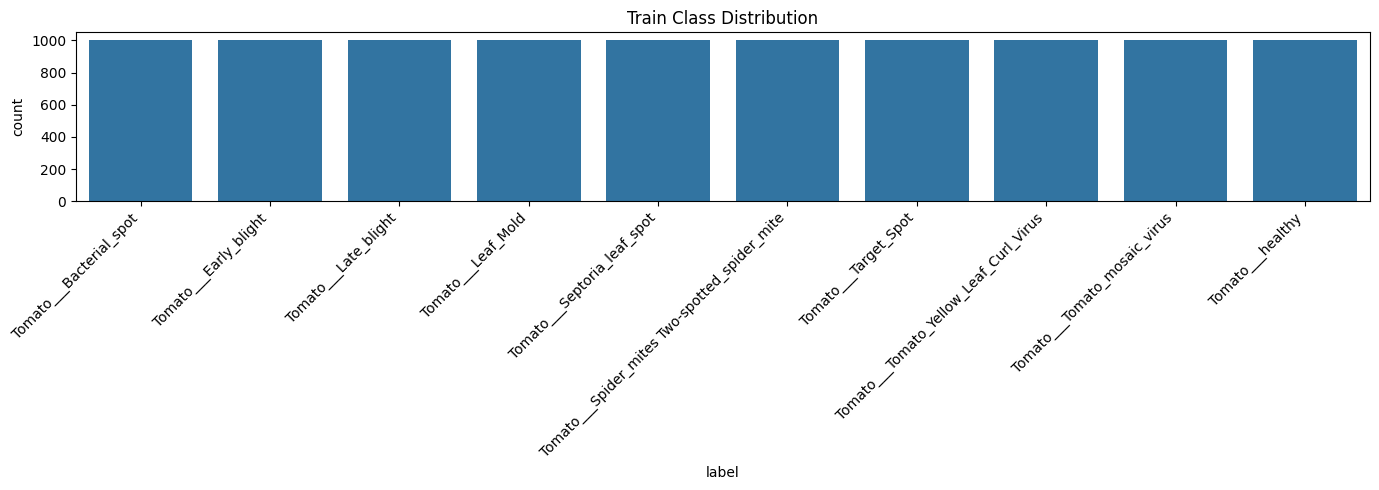

label
Tomato___Bacterial_spot                          0.1
Tomato___Early_blight                            0.1
Tomato___Late_blight                             0.1
Tomato___Leaf_Mold                               0.1
Tomato___Septoria_leaf_spot                      0.1
Tomato___Spider_mites Two-spotted_spider_mite    0.1
Tomato___Target_Spot                             0.1
Tomato___Tomato_Yellow_Leaf_Curl_Virus           0.1
Tomato___Tomato_mosaic_virus                     0.1
Tomato___healthy                                 0.1
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(14, 5))
sns.countplot(data=train_df, x='label', order=train_df['label'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Train Class Distribution')
plt.tight_layout()
plt.show()

print(train_df['label'].value_counts(normalize=True).round(3))

In [ ]:
sizes = []
for _, row in tqdm(train_df.sample(min(500, len(train_df))).iterrows(), total=500, desc='Checking sizes'):
    img = cv2.imread(row['filepath'])
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=['Height', 'Width'])
print(sizes_df.value_counts().head(10))

Checking sizes: 100%|██████████| 500/500 [00:03<00:00, 135.97it/s]

Height  Width
256     256      475
375     500        2
150     150        1
212     575        1
210     450        1
258     430        1
263     386        1
297     500        1
298     442        1
400     600        1
Name: count, dtype: int64


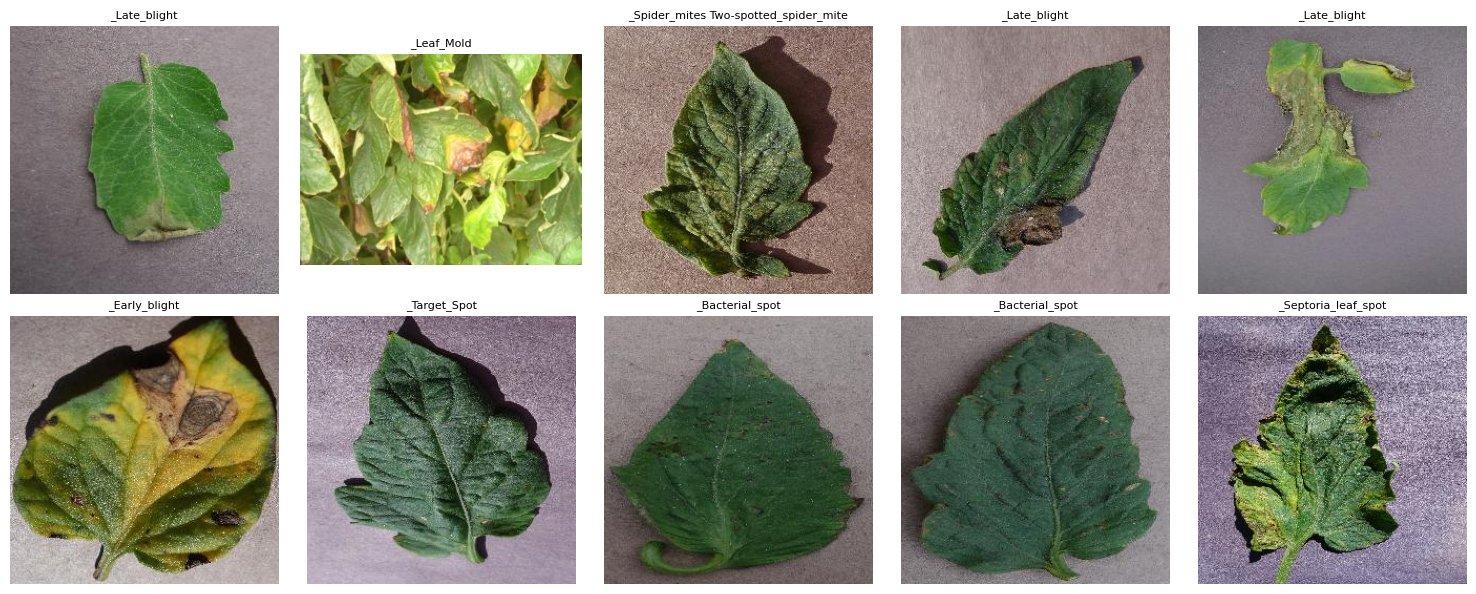

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax in axes.flatten():
    idx = random.randint(0, len(train_df) - 1)
    row = train_df.iloc[idx]
    img = cv2.imread(row['filepath'])
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(row['label'].replace('Tomato__', '').replace('Tomato_', ''), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
bad_images = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc='Checking corrupted'):
    if cv2.imread(row['filepath']) is None:
        bad_images.append(row['filepath'])
print('Corrupted images:', len(bad_images))

# Remove corrupted from df
if bad_images:
    train_df = train_df[~train_df['filepath'].isin(bad_images)].reset_index(drop=True)

Checking corrupted: 100%|██████████| 10000/10000 [00:13<00:00, 730.59it/s]

Corrupted images: 0


In [ ]:
IMG_SIZE = 384

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.4),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(p=0.3),
    A.RandomShadow(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.ImageCompression(quality_lower=75, quality_upper=100, p=0.2),
    A.Perspective(scale=(0.05, 0.1), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

valid_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_11368/932008354.py:14: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
/tmp/ipykernel_11368/932008354.py:15: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, quality_upper=100, p=0.2),


In [ ]:
class TomatoDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['filepath'])
        if img is None:
            raise ValueError(f'Image not found: {row["filepath"]}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)['image']
        return img, torch.tensor(row['label_id'], dtype=torch.long)

train_dataset = TomatoDataset(train_df, train_transforms)
val_dataset   = TomatoDataset(val_df,   valid_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 656 | Val batches: 63


In [ ]:
def build_model(model_name):
    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
    return model.to(device)

models_dict = {
    'resnet50':        build_model('resnet50'),
    'efficientnet_b3': build_model('efficientnet_b3'),
    'densenet121':     build_model('densenet121'),
    'vit_base':        build_model('vit_base_patch16_384')
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

In [ ]:
def evaluate(model, model_name="model"):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(predictions)
            targets.extend(labels.numpy())

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average='weighted')

    print(f"[{model_name}] Validation Accuracy: {acc:.4f} | F1: {f1:.4f}")

    return acc, f1

In [ ]:
def train_model(model, epochs=15, model_name='model'):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda')

    train_losses, train_accuracies = [], []
    val_accuracies, val_f1_scores = [], []

    # Early stopping
    best_val_acc = 0
    patience = 4
    patience_counter = 0
    best_model_path = f'{model_name}_best.pth'

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [{model_name}]'):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        scheduler.step()

        val_acc, val_f1 = evaluate(model, model_name)
        val_accuracies.append(val_acc)
        val_f1_scores.append(val_f1)

        print(f'\nEpoch {epoch+1}/{epochs} [{model_name}]')
        print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Accuracy: {val_acc:.4f} | Val F1: {val_f1:.4f}')

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f'  ✓ Best model saved (val_acc: {best_val_acc:.4f})')
        else:
            patience_counter += 1
            print(f'  No improvement. Patience: {patience_counter}/{patience}')
            if patience_counter >= patience:
                print(f'  Early stopping triggered at epoch {epoch+1}')
                break

        print('-' * 40)

    # Load best weights before returning
    model.load_state_dict(torch.load(best_model_path))
    print(f'\nLoaded best weights: val_acc={best_val_acc:.4f}')

    return {
        'train_loss': train_losses,
        'train_accuracy': train_accuracies,
        'val_accuracy': val_accuracies,
        'val_f1': val_f1_scores
    }

In [ ]:
#model = models_dict['efficientnet_b3']
#model_results = train_model(model, epochs=5, model_name='efficientnet_b3')

In [ ]:
#for name, mdl in models_dict.items():
#    if name != 'efficientnet_b3':  # skip already trained
#        train_model(mdl, epochs=5, model_name=name)

In [ ]:
def plot_confusion(model, model_name='model'):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(predictions)
            targets.extend(labels.numpy())

    cm     = confusion_matrix(targets, preds)
    labels = [id2label[i].replace('Tomato__','').replace('Tomato_','') for i in range(NUM_CLASSES)]
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#plot_confusion(model, 'efficientnet_b3')

In [ ]:
# def plot_metrics(results, model_name):
#     epochs = range(1, len(results['train_loss']) + 1)

#     plt.figure(figsize=(15, 5))

#     plt.subplot(1, 3, 1)
#     plt.plot(epochs, results['train_loss'], label='Training Loss')
#     plt.title(f'{model_name} Training Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.legend()

#     plt.subplot(1, 3, 2)
#     plt.plot(epochs, results['val_accuracy'], label='Validation Accuracy')
#     plt.title(f'{model_name} Validation Accuracy')
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy')
#     plt.legend()

#     plt.subplot(1, 3, 3)
#     plt.plot(epochs, results['val_f1'], label='Validation F1-Score')
#     plt.title(f'{model_name} Validation F1-Score')
#     plt.xlabel('Epoch')
#     plt.ylabel('F1-Score')
#     plt.legend()

#     plt.tight_layout()
#     plt.show()

# plot_metrics(model_results, 'efficientnet_b3')

In [ ]:
from torch.cuda.amp import autocast, GradScaler

In [ ]:
histories = {}

model = build_model('efficientnet_b3')
history = train_model(model, epochs=15, model_name='efficientnet_b3')
histories['efficientnet_b3'] = history

Epoch 1/15 [efficientnet_b3]: 100%|██████████| 656/656 [03:29<00:00,  3.13it/s]


[efficientnet_b3] Validation Accuracy: 0.9640 | F1: 0.9639

Epoch 1/15 [efficientnet_b3]
Train Loss: 1.1921 | Train Acc: 0.7273
Val Accuracy: 0.9640 | Val F1: 0.9639
  ✓ Best model saved (val_acc: 0.9640)
----------------------------------------


Epoch 2/15 [efficientnet_b3]: 100%|██████████| 656/656 [02:58<00:00,  3.68it/s]


[efficientnet_b3] Validation Accuracy: 0.9780 | F1: 0.9779

Epoch 2/15 [efficientnet_b3]
Train Loss: 0.8284 | Train Acc: 0.8747
Val Accuracy: 0.9780 | Val F1: 0.9779
  ✓ Best model saved (val_acc: 0.9780)
----------------------------------------


Epoch 3/15 [efficientnet_b3]: 100%|██████████| 656/656 [02:57<00:00,  3.70it/s]


...

[efficientnet_b3] Validation Accuracy: 0.9970 | F1: 0.9970

Epoch 13/15 [efficientnet_b3]
Train Loss: 0.5500 | Train Acc: 0.9828
Val Accuracy: 0.9970 | Val F1: 0.9970
  No improvement. Patience: 1/4
----------------------------------------


Epoch 14/15 [efficientnet_b3]: 100%|██████████| 656/656 [02:58<00:00,  3.68it/s]


[efficientnet_b3] Validation Accuracy: 0.9980 | F1: 0.9980

Epoch 14/15 [efficientnet_b3]
Train Loss: 0.5491 | Train Acc: 0.9831
Val Accuracy: 0.9980 | Val F1: 0.9980
  No improvement. Patience: 2/4
----------------------------------------


Epoch 15/15 [efficientnet_b3]: 100%|██████████| 656/656 [02:56<00:00,  3.71it/s]


[efficientnet_b3] Validation Accuracy: 0.9970 | F1: 0.9970

Epoch 15/15 [efficientnet_b3]
Train Loss: 0.5443 | Train Acc: 0.9858
Val Accuracy: 0.9970 | Val F1: 0.9970
  No improvement. Patience: 3/4
----------------------------------------

Loaded best weights: val_acc=0.9990


In [ ]:
print("\n======= FINAL RESULTS =======")

for name, history in histories.items():
    final_acc = history['val_accuracy'][-1]
    final_f1  = history['val_f1'][-1]

    print(f"{name.upper():15} | Final Val Accuracy: {final_acc:.4f} | Final F1: {final_f1:.4f}")


======= FINAL RESULTS =======
EFFICIENTNET_B3 | Final Val Accuracy: 0.9970 | Final F1: 0.9970


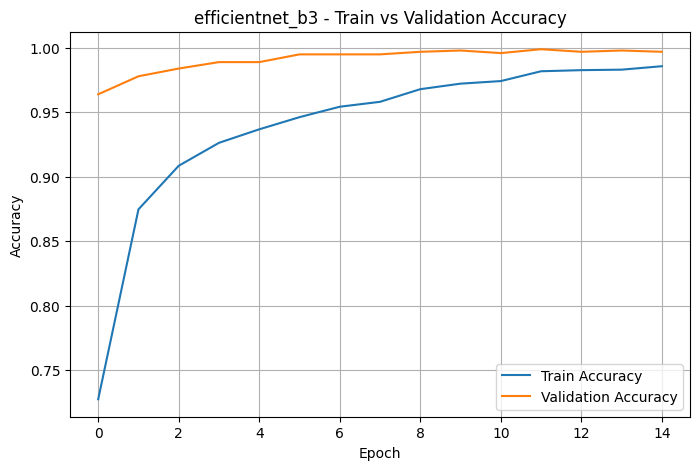

In [ ]:
for name, history in histories.items():
    plt.figure(figsize=(8,5))
    plt.plot(history['train_accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')

    plt.title(f"{name} - Train vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

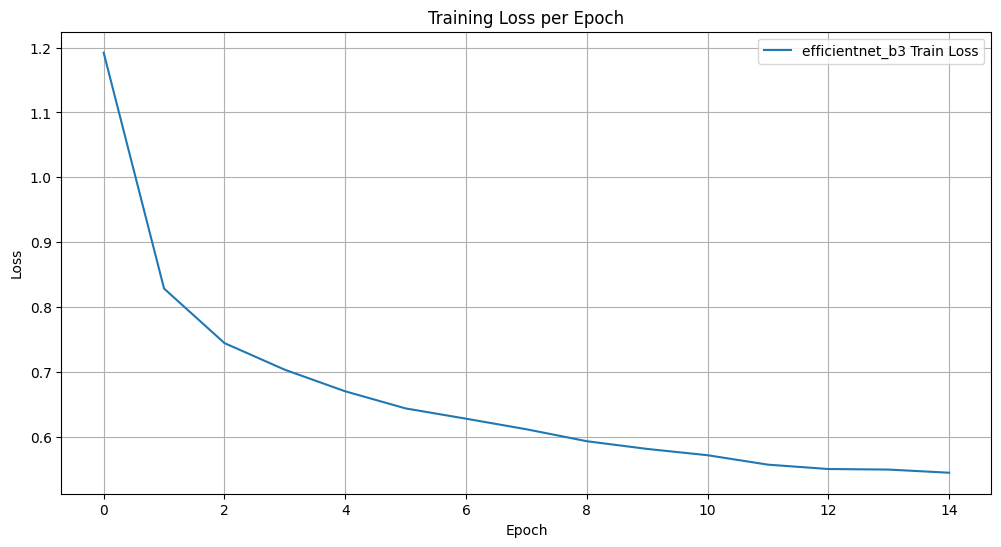

In [ ]:
plt.figure(figsize=(12,6))

for name, history in histories.items():
    plt.plot(history['train_loss'], label=f"{name} Train Loss")

plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

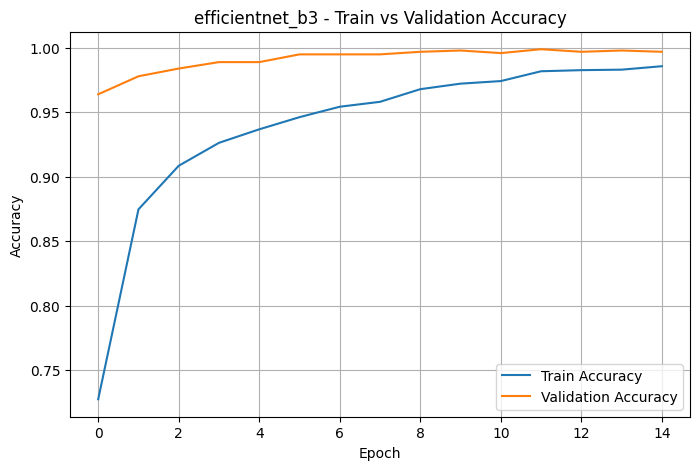

In [ ]:
for name, history in histories.items():
    plt.figure(figsize=(8,5))

    plt.plot(history['train_accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')

    plt.title(f"{name} - Train vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

## **Model Saving**

In [ ]:
import json

best_model_name = 'efficientnet_b3'
best_model = model  # already has best weights loaded from early stopping

# Save properly with torch.save — NOT h5py
torch.save(best_model.state_dict(), 'tomato_model.pth')

# Save label mapping
with open('tomato_label_mapping.json', 'w') as f:
    json.dump({
        'label2id': label2id,
        'id2label': {str(k): v for k, v in id2label.items()},
        'num_classes': NUM_CLASSES,
        'img_size': IMG_SIZE,
        'model_name': best_model_name
    }, f, indent=2)

print('Saved: tomato_model.pth and tomato_label_mapping.json')

# Download both files
from google.colab import files
files.download('tomato_model.pth')
files.download('tomato_label_mapping.json')

Saved: tomato_model.pth and tomato_label_mapping.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

best_model_name = 'efficientnet_b3'
best_model = model  # already has best weights loaded from early stopping

# Save properly with torch.save — NOT h5py
torch.save(best_model.state_dict(), 'tomato_model.pth')

# Save label mapping
with open('tomato_label_mapping.json', 'w') as f:
    json.dump({
        'label2id': label2id,
        'id2label': {str(k): v for k, v in id2label.items()},
        'num_classes': NUM_CLASSES,
        'img_size': IMG_SIZE,
        'model_name': best_model_name
    }, f, indent=2)

print('Saved: tomato_model.pth and tomato_label_mapping.json')

# Download both files
from google.colab import files
files.download('tomato_model.pth')
files.download('tomato_label_mapping.json')

In [ ]:
import json, h5py, numpy as np

# 1. Pick the best model
best_model_name = max(histories, key=lambda n: max(histories[n]['val_accuracy']))
best_model = models_dict[best_model_name]
print(f"Best model: {best_model_name}")

# 2. Save weights to .h5
with h5py.File("tomato_model.h5", "w") as hf:
    weights_group = hf.create_group("weights")
    for k, v in best_model.state_dict().items():
        parts = k.replace(".", "/")
        data = v.cpu().numpy()
        if data.shape == ():
            weights_group.create_dataset(parts, data=data)
        else:
            weights_group.create_dataset(parts, data=data, compression="gzip")
    meta = {
        "model_name": best_model_name,
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
    }
    hf.attrs["metadata"] = json.dumps(meta)

# 3. Save label mapping
with open("tomato_label_mapping.json", "w") as f:
    json.dump({
        "label2id": label2id,
        "id2label": {str(k): v for k, v in id2label.items()},
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
        "model_name": best_model_name
    }, f, indent=2)

print("Saved: tomato_model.h5 and tomato_label_mapping.json")

### TESTING

In [ ]:
from google.colab import files
import os

# Create a folder for your test images
os.makedirs('/content/test_images', exist_ok=True)

# Upload your images
uploaded = files.upload()

# Move them to the test folder
for fname in uploaded.keys():
    os.rename(f'/content/{fname}', f'/content/test_images/{fname}')

print(f'Uploaded {len(uploaded)} images')

Saving healthy.jpg to healthy.jpg
Saving healthy2.jpg to healthy2.jpg
Saving healthy3.jpg to healthy3.jpg
Saving leaf_mold.jpg to leaf_mold.jpg
Saving leaf_mold2.jpg to leaf_mold2.jpg
Saving leaf_mold3.jpg to leaf_mold3.jpg
Uploaded 6 images


In [ ]:
import torch
import cv2
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

def predict_image(model, image_path, transforms, id2label, device):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not read: {image_path}')
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    transformed = transforms(image=img)['image']
    input_tensor = transformed.unsqueeze(0).to(device)  # add batch dimension

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_id = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_id].item()

    predicted_label = id2label[predicted_id].replace('Tomato___', '')

    # Top 3 predictions
    top3 = torch.topk(probabilities, 3)
    top3_labels = [(id2label[idx.item()].replace('Tomato___', ''), prob.item())
                   for idx, prob in zip(top3.indices, top3.values)]

    return {
        'predicted': predicted_label,
        'confidence': confidence,
        'top3': top3_labels,
        'image': img
    }


# Run on all test images
TEST_FOLDER = '/content/test_images'
test_images = [f for f in os.listdir(TEST_FOLDER)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'Testing on {len(test_images)} images...\n')

results = []
for fname in test_images:
    path = os.path.join(TEST_FOLDER, fname)
    result = predict_image(model, path, valid_transforms, id2label, device)
    if result:
        result['filename'] = fname
        results.append(result)
        print(f'Image: {fname}')
        print(f'  Predicted: {result["predicted"]} ({result["confidence"]*100:.1f}%)')
        print(f'  Top 3: {[(l, f"{p*100:.1f}%") for l, p in result["top3"]]}')
        print()

Testing on 6 images...

Image: healthy3.jpg
  Predicted: Late_blight (33.2%)
  Top 3: [('Late_blight', '33.2%'), ('Leaf_Mold', '16.3%'), ('healthy', '12.6%')]

Image: leaf_mold.jpg
  Predicted: Leaf_Mold (86.8%)
  Top 3: [('Leaf_Mold', '86.8%'), ('Septoria_leaf_spot', '2.0%'), ('Early_blight', '1.9%')]

Image: leaf_mold2.jpg
  Predicted: Leaf_Mold (86.6%)
  Top 3: [('Leaf_Mold', '86.6%'), ('healthy', '2.2%'), ('Late_blight', '1.9%')]

Image: leaf_mold3.jpg
  Predicted: Leaf_Mold (89.8%)
  Top 3: [('Leaf_Mold', '89.8%'), ('healthy', '1.8%'), ('Bacterial_spot', '1.4%')]

Image: healthy2.jpg
  Predicted: healthy (89.6%)
  Top 3: [('healthy', '89.6%'), ('Leaf_Mold', '2.5%'), ('Bacterial_spot', '1.9%')]

Image: healthy.jpg
  Predicted: healthy (89.0%)
  Top 3: [('healthy', '89.0%'), ('Bacterial_spot', '3.0%'), ('Tomato_Yellow_Leaf_Curl_Virus', '1.2%')]



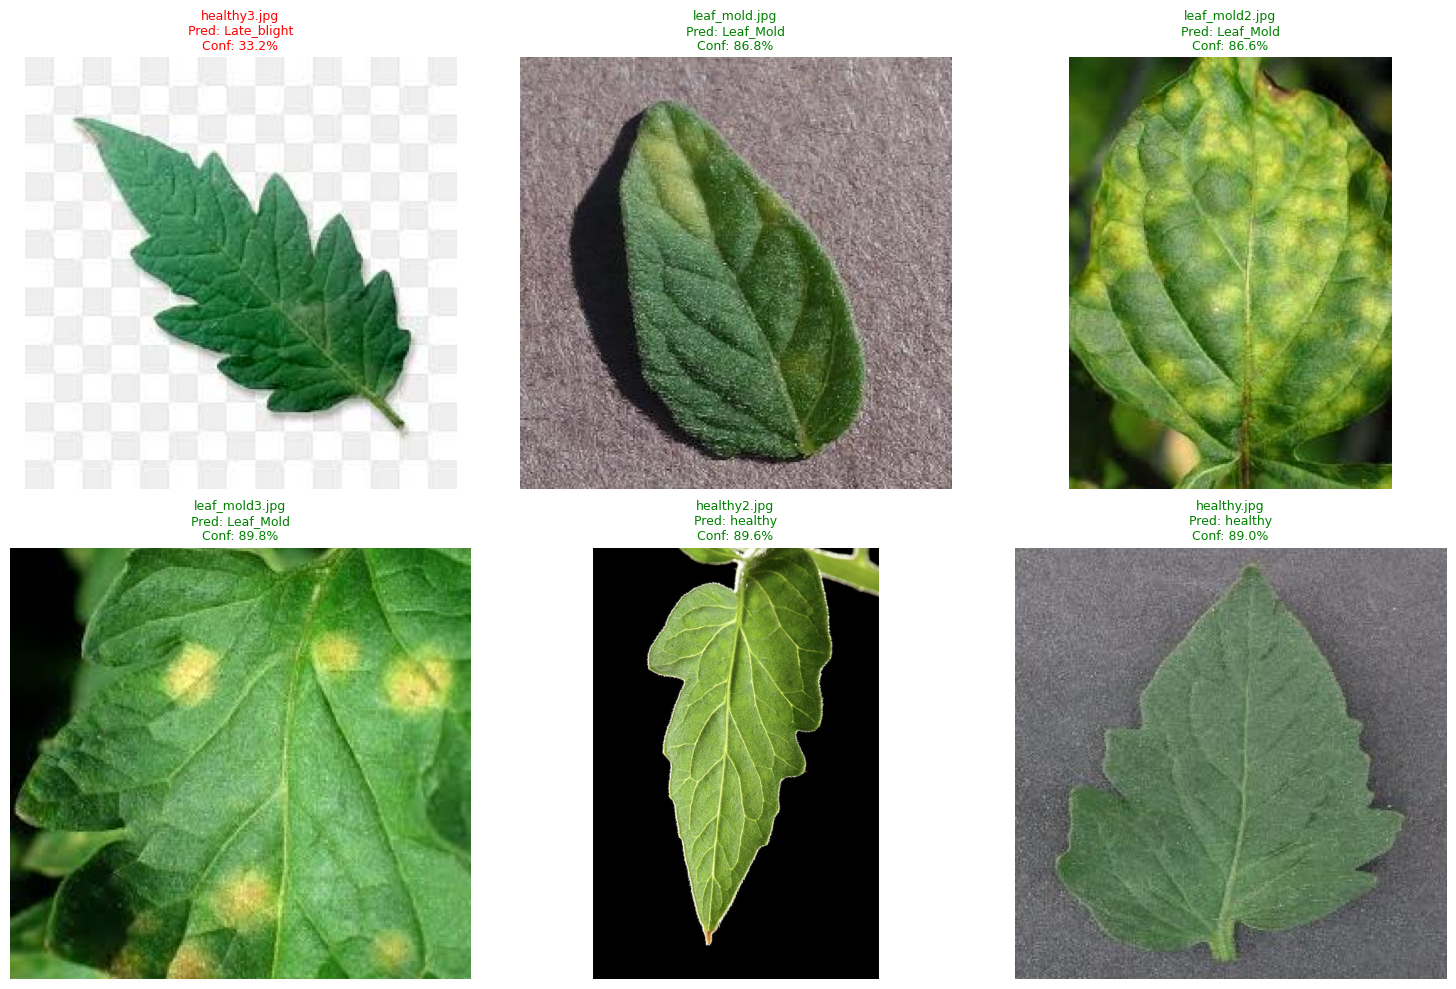

In [ ]:
cols = 3
rows = (len(results) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

for i, result in enumerate(results):
    axes[i].imshow(result['image'])
    axes[i].set_title(
        f"{result['filename']}\n"
        f"Pred: {result['predicted']}\n"
        f"Conf: {result['confidence']*100:.1f}%",
        fontsize=9,
        color='green' if result['confidence'] > 0.8 else 'orange' if result['confidence'] > 0.5 else 'red'
    )
    axes[i].axis('off')

# Hide empty subplots
for j in range(len(results), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()